# Online Courses: Complete Data-Cleaning Workflow

## tl;dr

- The raw file contains **8,092 scraped rows** from Coursera, FutureLearn, Udacity, and Simplilearn.
- The four platforms use different schemas, so most blank cells are **structural missingness**, not data errors. No blanket imputation is used.
- Five exact Udacity duplicates are removed. FutureLearn's 4,843 scraped appearances are consolidated into **2,031 unique course URLs**.
- The final analytical table contains **5,275 course-level records**, no exact duplicates, and a unique source-aware `course_key`.
- Ratings, audience counts, prices, durations, weekly study time, and explicit study-hour estimates are parsed without inventing unavailable values.
- A separate **24-column machine-learning view** retains course-interest, rating, popularity, and duration information while excluding sparse marketing and administrative fields.

The notebook is designed to run from top to bottom. Put `Online_Courses.csv` next to this notebook. The fallback path `upload/Online_Courses.csv` supports the current workspace layout.

## 1. Context & methods

### Analytical grain

The target grain is **one row per course or program**, not one row per scraped page appearance.

### Key assumptions

1. A URL identifies a course for Coursera, FutureLearn, and Udacity.
2. Two Simplilearn courses can share a generic URL, so Simplilearn uses title as the fallback identity.
3. FutureLearn columns such as `courses`, `experttracks`, and `topics_related_to_crm` describe the listing page rather than the individual course. They are excluded from the course-level table.
4. Missing values are not imputed. A value is parsed only when it is present and its meaning is defensible.
5. Study hours are estimated only when the source explicitly provides workload hours, or FutureLearn provides both duration and weekly study time.

## 2. Setup and load data

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
PLATFORM_COLORS = {
    "Coursera": "#2F6690",
    "Future Learn": "#D99B2B",
    "Udacity": "#6B7F3F",
    "Simplilearn": "#C65D3B",
}

DATA_CANDIDATES = [
    Path("Online_Courses.csv"),
    Path("upload/Online_Courses.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Online_Courses.csv was not found. Put it next to this notebook."
    )

OUTPUT_CSV = Path("Online_Courses_clean.csv")
ML_OUTPUT_CSV = Path("Online_Courses_ml_features.csv")

raw = pd.read_csv(DATA_PATH)
print(f"Loaded {raw.shape[0]:,} rows and {raw.shape[1]} columns from {DATA_PATH}")

Loaded 8,092 rows and 45 columns from Online_Courses.csv


In [2]:
initial_summary = pd.DataFrame({
    "metric": ["rows", "columns", "fully duplicated rows", "missing titles", "missing URLs"],
    "value": [
        len(raw),
        raw.shape[1],
        raw.duplicated().sum(),
        raw["Title"].isna().sum(),
        raw["URL"].isna().sum(),
    ],
})

display(initial_summary)
display(raw.head(3))

,metric,value
0,rows,8092
1,columns,45
2,fully duplicated rows,0
3,missing titles,0
4,missing URLs,0


,Unnamed: 0,Title,URL,Short Intro,Category,Sub-Category,Course Type,Language,Subtitle Languages,Skills,Instructors,Rating,Number of viewers,Duration,Site,Program Type,Courses,Level,Number of Reviews,Unique Projects,Prequisites,What you learn,Related Programs,Monthly access,6-Month access,4-Month access,3-Month access,5-Month access,2-Month access,School,Topics related to CRM,ExpertTracks,FAQs,Course Title,Course URL,Course Short Intro,Weekly study,Premium course,What's include,Rank,Created by,Program,Number of ratings,Price,COURSE CATEGORIES
0,0,Machine Learning Specialization,https://www.coursera.org/specializations/machine-learning-introduction,#BreakIntoAI with Machine Learning Specialization. Master fundamental AI concepts and develop practical machine lear...,Data Science,Machine Learning,Specialization,English,Subtitles: English,"Decision Trees, Artificial Neural Network, Logistic Regression, Recommender Systems, Linear Regression, Regularizati...","Andrew Ng ,Eddy Shyu ,Aarti Bagul ,Geoff Ladwig ,",4.9stars,"10,438",Approximately 3 months to complete,Coursera,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Introduction to Data Science Specialization,https://www.coursera.org/specializations/introduction-data-science,Launch your career in data science. Gain foundational data science skills to prepare for a career or further advance...,Data Science,Data Analysis,Specialization,English,"Subtitles: English, Arabic, French, Portuguese (European), Italian, Vietnamese, German, Russian, Turkish, Spanish, P...","Data Science, Relational Database Management System (RDBMS), Cloud Databases, Python Programming, SQL, Deep Learning...","Rav Ahuja ,Alex Aklson ,Aije Egwaikhide ,Svetlana Levitan ,Romeo Kienzler ,Polong Lin ,Hima Vasudevan ,",4.7stars,"11,927",Approximately 5 months to complete,Coursera,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Data Science Fundamentals with Python and SQL Specialization,https://www.coursera.org/specializations/data-science-fundamentals-python-sql,"Build the Foundation for your Data Science career. Develop hands-on experience with Jupyter, Python, SQL. Perform St...",Data Science,Data Analysis,Specialization,English,"Subtitles: English, Arabic, French, Portuguese (European), Italian, Vietnamese, German, Russian, Spanish, Persian, K...","Data Science, Github, Python Programming, Jupyter notebooks, Rstudio, Data Analysis, Pandas, Numpy, Probability And ...","Aije Egwaikhide ,Svetlana Levitan ,Romeo Kienzler ,Joseph Santarcangelo ,Azim Hirjani ,Murtaza Haider ,Rav Ahuja ,Hi...",4.6stars,"2,295",Approximately 7 months to complete,Coursera,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Standardize the raw schema

The exported index and the entirely empty `Unique Projects` column contain no information. Column names and whitespace are standardized before any comparisons are made.

In [3]:
df = raw.drop(columns=["Unnamed: 0", "Unique Projects"]).copy()

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

df = df.rename(columns={"prequisites": "prerequisites"})

string_columns = df.select_dtypes(include="str").columns
for column in string_columns:
    df[column] = (
        df[column]
          .str.strip()
          .replace("", pd.NA)
          .str.replace(r"\s+", " ", regex=True)
    )

print(f"Standardized shape: {df.shape}")
display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str)}).head(15))

Standardized shape: (8092, 43)


,column,dtype
title,title,str
url,url,str
short_intro,short_intro,str
category,category,str
sub_category,sub_category,str
course_type,course_type,str
language,language,str
subtitle_languages,subtitle_languages,str
skills,skills,str
instructors,instructors,str


### Platform-specific schema coverage

In [4]:
platform_schema = []
for site, group in df.groupby("site", sort=False):
    platform_schema.append({
        "site": site,
        "rows": len(group),
        "active_columns": int((group.notna().sum() > 0).sum()),
        "unique_titles": group["title"].nunique(),
        "unique_urls": group["url"].nunique(),
        "duplicate_titles": int(group.duplicated("title").sum()),
        "duplicate_urls": int(group.duplicated("url").sum()),
    })

platform_schema = pd.DataFrame(platform_schema)
display(platform_schema)

,site,rows,active_columns,unique_titles,unique_urls,duplicate_titles,duplicate_urls
0,Coursera,2819,14,2565,2819,254,0
1,Udacity,282,21,275,277,7,5
2,Future Learn,4843,15,1935,2031,2908,2812
3,Simplilearn,148,10,148,146,0,2


The platform split shows why global null percentages are misleading. For example, Coursera supplies `language` and `instructors`, FutureLearn supplies `weekly_study`, Udacity supplies `school` and `program_type`, and Simplilearn supplies `course_categories` and `price`.

## 4. Diagnose and resolve duplicates

In [5]:
duplicate_diagnostics = []
for site, group in df.groupby("site", sort=False):
    duplicate_diagnostics.append({
        "site": site,
        "rows_before": len(group),
        "exact_duplicates": int(group.duplicated().sum()),
        "duplicate_titles": int(group.duplicated("title").sum()),
        "duplicate_urls": int(group.duplicated("url").sum()),
    })

duplicate_diagnostics = pd.DataFrame(duplicate_diagnostics)
display(duplicate_diagnostics)

print("Exact duplicate rows:", df.duplicated().sum())

,site,rows_before,exact_duplicates,duplicate_titles,duplicate_urls
0,Coursera,2819,0,254,0
1,Udacity,282,5,7,5
2,Future Learn,4843,0,2908,2812
3,Simplilearn,148,0,0,2


Exact duplicate rows: 5


Repeated titles are not a safe deduplication key: Coursera and Udacity contain different URLs with the same title. Repeated Simplilearn URLs are also not automatically duplicates because generic landing-page URLs are reused. Exact duplicates can be removed safely.

In [6]:
df = df.drop_duplicates().reset_index(drop=True)

futurelearn = df[df["site"] == "Future Learn"].copy()

redundant_futurelearn_checks = pd.DataFrame({
    "pair": [
        "title vs course_title",
        "url vs course_url",
        "short_intro vs course_short_intro",
    ],
    "agreement_rate": [
        futurelearn["title"].eq(futurelearn["course_title"]).mean(),
        futurelearn["url"].eq(futurelearn["course_url"]).mean(),
        futurelearn["short_intro"].eq(futurelearn["course_short_intro"]).mean(),
    ],
})

display(redundant_futurelearn_checks)

,pair,agreement_rate
0,title vs course_title,1.00
1,url vs course_url,1.00
2,short_intro vs course_short_intro,1.00


In [7]:
df = df.drop(columns=["course_title", "course_url", "course_short_intro"])
futurelearn = df[df["site"] == "Future Learn"].copy()

duplicate_fl = futurelearn[futurelearn.duplicated("url", keep=False)]
varying_fields = []
for column in [
    "title", "short_intro", "duration", "weekly_study",
    "courses", "topics_related_to_crm", "experttracks", "faqs",
]:
    varying_groups = (
        duplicate_fl.groupby("url")[column]
        .nunique(dropna=False)
        .gt(1)
        .sum()
    )
    varying_fields.append({"field": column, "duplicate_url_groups_that_vary": varying_groups})

display(pd.DataFrame(varying_fields).sort_values("duplicate_url_groups_that_vary", ascending=False))

,field,duplicate_url_groups_that_vary
4,courses,1493
5,topics_related_to_crm,1492
6,experttracks,1476
7,faqs,797
1,short_intro,15
3,weekly_study,0
0,title,0
2,duration,0


`courses`, `topics_related_to_crm`, and `experttracks` vary primarily because they describe the FutureLearn listing page. They are not aggregated into course attributes. For genuine course fields, the longest available description or FAQ is retained, and the first available non-null value is used for stable fields.

In [8]:
def first_non_null(series):
    values = series.dropna()
    return values.iloc[0] if len(values) else pd.NA


def longest_text(series):
    values = series.dropna().astype("string")
    if len(values) == 0:
        return pd.NA
    return values.loc[values.str.len().idxmax()]


futurelearn_clean = (
    futurelearn.groupby("url", as_index=False)
    .agg({
        "title": "first",
        "short_intro": longest_text,
        "duration": first_non_null,
        "site": "first",
        "weekly_study": first_non_null,
        "premium_course": first_non_null,
        "what_s_include": first_non_null,
        "faqs": longest_text,
    })
)

# Recreate the standardized union schema. FutureLearn page-context fields remain empty.
for column in df.columns:
    if column not in futurelearn_clean.columns:
        futurelearn_clean[column] = pd.NA
futurelearn_clean = futurelearn_clean[df.columns]

other_sites = df[df["site"] != "Future Learn"].copy()
df_course = pd.concat([other_sites, futurelearn_clean], ignore_index=True)

# The overloaded `courses` field is meaningful only for Udacity after removing
# FutureLearn page-context values.
df_course = df_course.rename(columns={
    "courses": "included_courses",
    "what_s_include": "whats_included",
})
df_course = df_course.drop(columns=["topics_related_to_crm", "experttracks"])

rows_after = df_course["site"].value_counts().rename("rows_after").rename_axis("site")
dedup_summary = (
    raw["Site"].value_counts().rename("rows_before").rename_axis("site")
    .to_frame()
    .join(rows_after)
    .assign(rows_removed=lambda x: x["rows_before"] - x["rows_after"])
    .reset_index()
)

display(dedup_summary)

,site,rows_before,rows_after,rows_removed
0,Future Learn,4843,2031,2812
1,Coursera,2819,2819,0
2,Udacity,282,277,5
3,Simplilearn,148,148,0


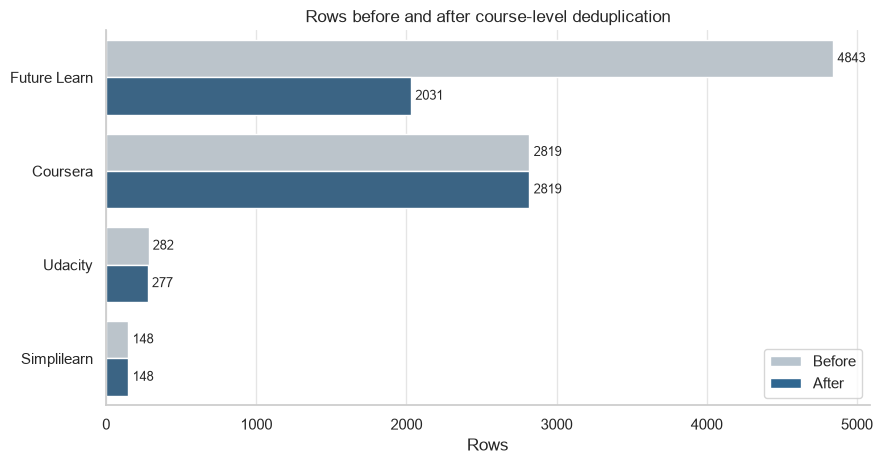

In [9]:
plot_data = dedup_summary.melt(
    id_vars="site",
    value_vars=["rows_before", "rows_after"],
    var_name="stage",
    value_name="rows",
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=plot_data,
    y="site",
    x="rows",
    hue="stage",
    palette={"rows_before": "#B8C4CE", "rows_after": "#2F6690"},
    ax=ax,
)
ax.set_title("Rows before and after course-level deduplication")
ax.set_xlabel("Rows")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)
from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(facecolor="#B8C4CE", label="Before"),
        Patch(facecolor="#2F6690", label="After"),
    ],
    title="",
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 5. Parse numeric fields

In [10]:
def extract_number(series):
    # Extract the first ordinary numeric token after removing thousands commas.
    text = series.astype("string").str.replace(",", "", regex=False)
    return pd.to_numeric(
        text.str.extract(r"([-+]?\d+(?:\.\d+)?)", expand=False),
        errors="coerce",
    )


df_course["rating_score"] = extract_number(df_course["rating"])
df_course["coursera_viewers"] = extract_number(df_course["number_of_viewers"])
df_course["udacity_viewers"] = extract_number(df_course["number_of_reviews"])
df_course["rating_count"] = extract_number(df_course["number_of_ratings"])
df_course["price_usd"] = pd.to_numeric(df_course["price"], errors="coerce")

# Both contributing fields explicitly contain viewer counts.
df_course["viewer_count"] = df_course["coursera_viewers"].combine_first(
    df_course["udacity_viewers"]
)

access_columns = [
    "monthly_access", "2_month_access", "3_month_access",
    "4_month_access", "5_month_access", "6_month_access",
]
for column in access_columns:
    df_course[f"{column}_usd"] = extract_number(df_course[column])

numeric_coverage = pd.DataFrame({
    "field": ["rating_score", "viewer_count", "rating_count", "price_usd"],
    "non_null": [df_course[c].notna().sum() for c in [
        "rating_score", "viewer_count", "rating_count", "price_usd"
    ]],
})
display(numeric_coverage)

,field,non_null
0,rating_score,2737
1,viewer_count,2737
2,rating_count,122
3,price_usd,65


In [11]:
malformed_rating_counts = df_course.loc[
    df_course["number_of_ratings"].notna() & df_course["rating_count"].isna(),
    ["site", "title", "number_of_ratings"],
]

print("Malformed rating-count values converted to missing:")
display(malformed_rating_counts)

invalid_ratings = df_course.loc[
    df_course["rating_score"].notna()
    & ~df_course["rating_score"].between(0, 5),
    ["site", "title", "rating", "rating_score"],
]
print("Ratings outside 0-5:", len(invalid_ratings))

Malformed rating-count values converted to missing:


,site,title,number_of_ratings
3163,Simplilearn,Full Stack Developer - MEAN Stack,ter'
3165,Simplilearn,UI/UX Design Expert,ter'
3166,Simplilearn,Automation Test Engineer,ter'
3167,Simplilearn,PMP® Certification Training Course,)


Ratings outside 0-5: 0


Udacity's source column is named `number_of_reviews`, but its values explicitly say “viewers.” It is therefore harmonized with Coursera's viewer count, not treated as a review count. Malformed Simplilearn rating-count strings are preserved as missing rather than guessed.

## 6. Parse duration and explicit workload

In [12]:
DURATION_PATTERN = re.compile(
    r"(\d+(?:\.\d+)?)\s*(?:-\s*(\d+(?:\.\d+)?))?\s*"
    r"(minutes?|hours?|horas?|days?|weeks?|months?)",
    flags=re.IGNORECASE,
)

UNIT_MAP = {
    "minute": "minute", "minutes": "minute",
    "hour": "hour", "hours": "hour", "hora": "hour", "horas": "hour",
    "day": "day", "days": "day",
    "week": "week", "weeks": "week",
    "month": "month", "months": "month",
}


def parse_duration(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, pd.NA], dtype="object")
    match = DURATION_PATTERN.search(str(value).lower())
    if match is None:
        return pd.Series([np.nan, np.nan, pd.NA], dtype="object")
    lower = float(match.group(1))
    upper = float(match.group(2)) if match.group(2) else lower
    unit = UNIT_MAP[match.group(3).lower()]
    return pd.Series([lower, upper, unit], dtype="object")


duration_parts = df_course["duration"].apply(parse_duration)
duration_parts.columns = ["duration_min", "duration_max", "duration_unit"]
df_course = pd.concat([df_course, duration_parts], axis=1)
df_course[["duration_min", "duration_max"]] = df_course[
    ["duration_min", "duration_max"]
].apply(pd.to_numeric, errors="coerce")

df_course["duration_basis"] = np.select(
    [
        df_course["duration_unit"].isin(["minute", "hour"]),
        df_course["duration_unit"].isin(["day", "week", "month"]),
    ],
    ["study_time", "elapsed_time"],
    default=None,
)

# Parse FutureLearn weekly hours and Coursera phrases such as
# "6 months at 10 hours a week".
df_course["weekly_study_hours"] = extract_number(df_course["weekly_study"])
weekly_from_duration = pd.to_numeric(
    df_course["duration"].astype("string")
    .str.extract(r"(?i)at\s+(\d+(?:\.\d+)?)\s+hours?\s+a\s+week", expand=False),
    errors="coerce",
)
df_course["weekly_study_hours"] = df_course["weekly_study_hours"].combine_first(
    weekly_from_duration
)

# A nonzero-duration course cannot require literally zero study hours. The three
# unique FutureLearn records reported as "0 hours" are treated as malformed.
zero_weekly_hours_mask = df_course["weekly_study_hours"].eq(0)
zero_weekly_hours_count = int(zero_weekly_hours_mask.sum())
df_course.loc[zero_weekly_hours_mask, "weekly_study_hours"] = np.nan

# Only compute total study hours where source semantics explicitly support it.
df_course["study_hours_estimate"] = np.nan

hours_mask = df_course["duration_unit"].eq("hour")
minutes_mask = df_course["duration_unit"].eq("minute")
futurelearn_mask = (
    df_course["site"].eq("Future Learn")
    & df_course["duration_unit"].eq("week")
    & df_course["weekly_study_hours"].notna()
)
coursera_schedule_mask = (
    df_course["site"].eq("Coursera")
    & df_course["duration_unit"].eq("month")
    & df_course["weekly_study_hours"].notna()
)

df_course.loc[hours_mask, "study_hours_estimate"] = df_course.loc[
    hours_mask, "duration_min"
]
df_course.loc[minutes_mask, "study_hours_estimate"] = (
    df_course.loc[minutes_mask, "duration_min"] / 60
)
df_course.loc[futurelearn_mask, "study_hours_estimate"] = (
    df_course.loc[futurelearn_mask, "duration_min"]
    * df_course.loc[futurelearn_mask, "weekly_study_hours"]
)
df_course.loc[coursera_schedule_mask, "study_hours_estimate"] = (
    df_course.loc[coursera_schedule_mask, "duration_min"]
    * 4.345
    * df_course.loc[coursera_schedule_mask, "weekly_study_hours"]
)

duration_quality = pd.DataFrame({
    "metric": [
        "non-null raw durations",
        "parsed durations",
        "unparsed non-null durations",
        "zero weekly-hour values set to missing",
        "explicit study-hour estimates",
    ],
    "value": [
        df_course["duration"].notna().sum(),
        df_course["duration_unit"].notna().sum(),
        (df_course["duration"].notna() & df_course["duration_unit"].isna()).sum(),
        zero_weekly_hours_count,
        df_course["study_hours_estimate"].notna().sum(),
    ],
})
display(duration_quality)

,metric,value
0,non-null raw durations,5127
1,parsed durations,5121
2,unparsed non-null durations,6
3,zero weekly-hour values set to missing,3
4,explicit study-hour estimates,4432


In [13]:
unparsed_durations = (
    df_course.loc[
        df_course["duration"].notna() & df_course["duration_unit"].isna(),
        ["site", "duration"],
    ]
    .drop_duplicates()
    .sort_values(["site", "duration"])
)

print("Unparsed non-null duration formats:")
display(unparsed_durations)

Unparsed non-null duration formats:


,site,duration
488,Coursera,Flexible schedule
2851,Udacity,Estimated timeApprox. undefined undefined


`Flexible schedule` and `undefined undefined` remain missing because neither supplies a numeric duration. Hours and minutes represent study workload, while days, weeks, and months usually represent elapsed duration. The `duration_basis` field preserves this distinction.

## 7. Harmonize cross-platform variables

In [14]:
df_course["category_harmonized"] = df_course["category"].combine_first(
    df_course["course_categories"]
)
df_course["offering_type"] = (
    df_course["course_type"]
    .combine_first(df_course["program_type"])
    .combine_first(df_course["program"])
)

# URL is reliable for three sources. Simplilearn needs title because generic URLs
# are shared by distinct courses.
identity_value = df_course["url"].where(
    ~df_course["site"].eq("Simplilearn"),
    df_course["title"],
)
df_course["course_key"] = df_course["site"] + "::" + identity_value

df_clean = df_course.rename(columns={
    "duration": "duration_raw",
    "weekly_study": "weekly_study_raw",
    "premium_course": "premium_course_details",
})

final_columns = [
    "course_key", "site", "title", "url", "short_intro",
    "category_harmonized", "sub_category", "offering_type",
    "language", "subtitle_languages", "level",
    "skills", "instructors", "school", "prerequisites", "what_you_learn",
    "related_programs", "included_courses",
    "duration_raw", "duration_min", "duration_max", "duration_unit",
    "duration_basis", "weekly_study_raw", "weekly_study_hours",
    "study_hours_estimate", "rating_score", "viewer_count", "rating_count",
    "price_usd", "monthly_access_usd", "2_month_access_usd",
    "3_month_access_usd", "4_month_access_usd", "5_month_access_usd",
    "6_month_access_usd", "premium_course_details", "whats_included",
    "faqs", "rank", "created_by",
]

df_clean = df_clean[final_columns].rename(columns={
    "category_harmonized": "category",
})

print(f"Final analytical shape: {df_clean.shape}")
display(df_clean.head(3))

Final analytical shape: (5275, 41)


,course_key,site,title,url,short_intro,category,sub_category,offering_type,language,subtitle_languages,level,skills,instructors,school,prerequisites,what_you_learn,related_programs,included_courses,duration_raw,duration_min,duration_max,duration_unit,duration_basis,weekly_study_raw,weekly_study_hours,study_hours_estimate,rating_score,viewer_count,rating_count,price_usd,monthly_access_usd,2_month_access_usd,3_month_access_usd,4_month_access_usd,5_month_access_usd,6_month_access_usd,premium_course_details,whats_included,faqs,rank,created_by
0,Coursera::https://www.coursera.org/specializations/machine-learning-introduction,Coursera,Machine Learning Specialization,https://www.coursera.org/specializations/machine-learning-introduction,#BreakIntoAI with Machine Learning Specialization. Master fundamental AI concepts and develop practical machine lear...,Data Science,Machine Learning,Specialization,English,Subtitles: English,NaN,"Decision Trees, Artificial Neural Network, Logistic Regression, Recommender Systems, Linear Regression, Regularizati...","Andrew Ng ,Eddy Shyu ,Aarti Bagul ,Geoff Ladwig ,",NaN,NaN,NaN,NaN,NaN,Approximately 3 months to complete,3.00,3.00,month,elapsed_time,NaN,<NA>,NaN,4.90,10438,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
1,Coursera::https://www.coursera.org/specializations/introduction-data-science,Coursera,Introduction to Data Science Specialization,https://www.coursera.org/specializations/introduction-data-science,Launch your career in data science. Gain foundational data science skills to prepare for a career or further advance...,Data Science,Data Analysis,Specialization,English,"Subtitles: English, Arabic, French, Portuguese (European), Italian, Vietnamese, German, Russian, Turkish, Spanish, P...",NaN,"Data Science, Relational Database Management System (RDBMS), Cloud Databases, Python Programming, SQL, Deep Learning...","Rav Ahuja ,Alex Aklson ,Aije Egwaikhide ,Svetlana Levitan ,Romeo Kienzler ,Polong Lin ,Hima Vasudevan ,",NaN,NaN,NaN,NaN,NaN,Approximately 5 months to complete,5.00,5.00,month,elapsed_time,NaN,<NA>,NaN,4.70,11927,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
2,Coursera::https://www.coursera.org/specializations/data-science-fundamentals-python-sql,Coursera,Data Science Fundamentals with Python and SQL Specialization,https://www.coursera.org/specializations/data-science-fundamentals-python-sql,"Build the Foundation for your Data Science career. Develop hands-on experience with Jupyter, Python, SQL. Perform St...",Data Science,Data Analysis,Specialization,English,"Subtitles: English, Arabic, French, Portuguese (European), Italian, Vietnamese, German, Russian, Spanish, Persian, K...",NaN,"Data Science, Github, Python Programming, Jupyter notebooks, Rstudio, Data Analysis, Pandas, Numpy, Probability And ...","Aije Egwaikhide ,Svetlana Levitan ,Romeo Kienzler ,Joseph Santarcangelo ,Azim Hirjani ,Murtaza Haider ,Rav Ahuja ,Hi...",NaN,NaN,NaN,NaN,NaN,Approximately 7 months to complete,7.00,7.00,month,elapsed_time,NaN,<NA>,NaN,4.60,2295,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN


## 8. Create the reduced machine-learning table

The full cleaned table remains available for auditing. The reduced table removes fields that are redundant, extremely sparse, platform-specific marketing material, or unsuitable as model inputs.

`course_key`, `site`, `title`, and `url` are retained as identifiers and serving metadata. They should not be treated as ordinary categorical or numerical predictors without a specific modeling reason.

In [15]:
metadata_columns = [
    "course_key", "site", "title", "url",
]

interest_feature_columns = [
    "short_intro", "category", "sub_category", "offering_type", "level",
    "language", "subtitle_languages", "skills", "prerequisites",
    "what_you_learn", "included_courses",
]

quality_and_time_columns = [
    "duration_min", "duration_max", "duration_unit", "duration_basis",
    "weekly_study_hours", "study_hours_estimate", "rating_score",
    "viewer_count", "rating_count",
]

ml_columns = (
    metadata_columns
    + interest_feature_columns
    + quality_and_time_columns
)

df_ml = df_clean[ml_columns].copy()

removed_columns = sorted(set(df_clean.columns) - set(ml_columns))
feature_selection_summary = pd.DataFrame({
    "table": ["Full cleaned table", "Reduced ML table", "Removed columns"],
    "columns": [df_clean.shape[1], df_ml.shape[1], len(removed_columns)],
})

display(feature_selection_summary)
print("Removed columns:")
print(", ".join(removed_columns))
display(df_ml.head(3))

,table,columns
0,Full cleaned table,41
1,Reduced ML table,24
2,Removed columns,17


Removed columns:
2_month_access_usd, 3_month_access_usd, 4_month_access_usd, 5_month_access_usd, 6_month_access_usd, created_by, duration_raw, faqs, instructors, monthly_access_usd, premium_course_details, price_usd, rank, related_programs, school, weekly_study_raw, whats_included


,course_key,site,title,url,short_intro,category,sub_category,offering_type,level,language,subtitle_languages,skills,prerequisites,what_you_learn,included_courses,duration_min,duration_max,duration_unit,duration_basis,weekly_study_hours,study_hours_estimate,rating_score,viewer_count,rating_count
0,Coursera::https://www.coursera.org/specializations/machine-learning-introduction,Coursera,Machine Learning Specialization,https://www.coursera.org/specializations/machine-learning-introduction,#BreakIntoAI with Machine Learning Specialization. Master fundamental AI concepts and develop practical machine lear...,Data Science,Machine Learning,Specialization,NaN,English,Subtitles: English,"Decision Trees, Artificial Neural Network, Logistic Regression, Recommender Systems, Linear Regression, Regularizati...",NaN,NaN,NaN,3.00,3.00,month,elapsed_time,<NA>,NaN,4.90,10438,<NA>
1,Coursera::https://www.coursera.org/specializations/introduction-data-science,Coursera,Introduction to Data Science Specialization,https://www.coursera.org/specializations/introduction-data-science,Launch your career in data science. Gain foundational data science skills to prepare for a career or further advance...,Data Science,Data Analysis,Specialization,NaN,English,"Subtitles: English, Arabic, French, Portuguese (European), Italian, Vietnamese, German, Russian, Turkish, Spanish, P...","Data Science, Relational Database Management System (RDBMS), Cloud Databases, Python Programming, SQL, Deep Learning...",NaN,NaN,NaN,5.00,5.00,month,elapsed_time,<NA>,NaN,4.70,11927,<NA>
2,Coursera::https://www.coursera.org/specializations/data-science-fundamentals-python-sql,Coursera,Data Science Fundamentals with Python and SQL Specialization,https://www.coursera.org/specializations/data-science-fundamentals-python-sql,"Build the Foundation for your Data Science career. Develop hands-on experience with Jupyter, Python, SQL. Perform St...",Data Science,Data Analysis,Specialization,NaN,English,"Subtitles: English, Arabic, French, Portuguese (European), Italian, Vietnamese, German, Russian, Spanish, Persian, K...","Data Science, Github, Python Programming, Jupyter notebooks, Rstudio, Data Analysis, Pandas, Numpy, Probability And ...",NaN,NaN,NaN,7.00,7.00,month,elapsed_time,<NA>,NaN,4.60,2295,<NA>


The reduced table excludes raw duration strings, duplicated price-plan fields, sparse provider fields, FAQs, ranking text, and premium-course marketing descriptions. Rating, rating volume, viewer popularity, and all normalized duration/workload fields remain available.

## 9. Missingness by platform

In [16]:
coverage_fields = [
    "short_intro", "category", "offering_type", "language", "skills",
    "rating_score", "viewer_count", "duration_unit",
    "weekly_study_hours", "study_hours_estimate", "price_usd",
]

coverage = (
    df_clean.groupby("site")[coverage_fields]
    .apply(lambda group: group.notna().mean().mul(100))
)

display(coverage.round(1))

,short_intro,category,offering_type,language,skills,rating_score,viewer_count,duration_unit,weekly_study_hours,study_hours_estimate,price_usd
site,,,,,,,,,,,
Coursera,98.40,100.00,100.00,100.00,70.90,95.60,95.60,99.90,2.80,85.20,0.00
Future Learn,100.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,99.90,99.90,0.00
Simplilearn,97.30,100.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,43.90
Udacity,98.60,0.00,100.00,0.00,34.70,15.20,15.20,98.60,0.00,0.40,0.00


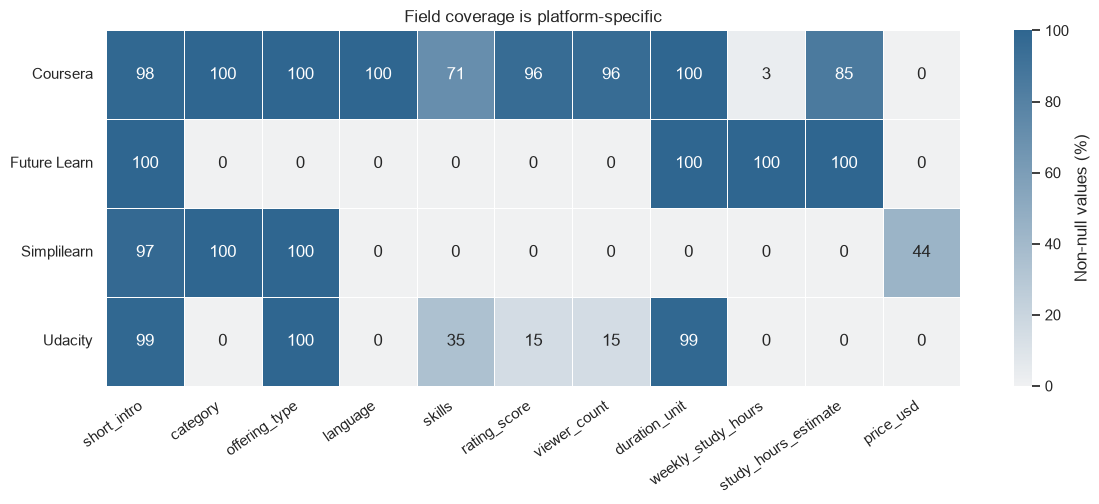

In [17]:
fig, ax = plt.subplots(figsize=(12, 5.2))
sns.heatmap(
    coverage,
    annot=True,
    fmt=".0f",
    cmap=sns.light_palette("#2F6690", as_cmap=True),
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Non-null values (%)"},
    ax=ax,
)
ax.set_title("Field coverage is platform-specific")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Zeros in the heatmap usually mean a platform does not provide that field. For example, language coverage is a Coursera feature, while price coverage comes from Simplilearn. This is structural missingness and is deliberately left as missing rather than filled with fabricated defaults.

## 10. Final validation and export

In [18]:
validation = pd.DataFrame({
    "check": [
        "rows",
        "columns",
        "missing titles",
        "missing URLs",
        "exact duplicate rows",
        "duplicate course keys",
        "ratings outside 0-5",
        "negative viewer counts",
        "negative rating counts",
        "negative prices",
    ],
    "result": [
        len(df_clean),
        df_clean.shape[1],
        df_clean["title"].isna().sum(),
        df_clean["url"].isna().sum(),
        df_clean.duplicated().sum(),
        df_clean["course_key"].duplicated().sum(),
        (df_clean["rating_score"].notna() & ~df_clean["rating_score"].between(0, 5)).sum(),
        (df_clean["viewer_count"] < 0).sum(),
        (df_clean["rating_count"] < 0).sum(),
        (df_clean["price_usd"] < 0).sum(),
    ],
})

display(validation)

assert len(df_clean) == 5_275
assert df_clean["course_key"].is_unique
assert not df_clean["title"].isna().any()
assert not df_clean["url"].isna().any()
assert df_clean.duplicated().sum() == 0
assert not (
    df_clean["rating_score"].notna()
    & ~df_clean["rating_score"].between(0, 5)
).any()

assert df_ml.shape == (5_275, 24)
assert df_ml["course_key"].is_unique

df_clean.to_csv(OUTPUT_CSV, index=False)
df_ml.to_csv(ML_OUTPUT_CSV, index=False)
print(f"Exported {len(df_clean):,} rows to {OUTPUT_CSV.resolve()}")
print(f"Exported {len(df_ml):,} rows to {ML_OUTPUT_CSV.resolve()}")

,check,result
0,rows,5275
1,columns,41
2,missing titles,0
3,missing URLs,0
4,exact duplicate rows,0
5,duplicate course keys,0
6,ratings outside 0-5,0
7,negative viewer counts,0
8,negative rating counts,0
9,negative prices,0


Exported 5,275 rows to C:\Users\bilgi\Documents\ChatGPT\Software-Engineering---Group-7\data\Online_Courses_clean.csv
Exported 5,275 rows to C:\Users\bilgi\Documents\ChatGPT\Software-Engineering---Group-7\data\Online_Courses_ml_features.csv


In [19]:
final_platform_summary = (
    df_clean.groupby("site")
    .agg(
        courses=("course_key", "size"),
        categories_available=("category", "count"),
        ratings_available=("rating_score", "count"),
        viewers_available=("viewer_count", "count"),
        study_hours_available=("study_hours_estimate", "count"),
        prices_available=("price_usd", "count"),
    )
    .reset_index()
)

display(final_platform_summary)

,site,courses,categories_available,ratings_available,viewers_available,study_hours_available,prices_available
0,Coursera,2819,2819,2695,2695,2403,0
1,Future Learn,2031,0,0,0,2028,0
2,Simplilearn,148,148,0,0,0,65
3,Udacity,277,0,42,42,1,0


## 11. Takeaways

- The cleaned data contains **5,275 distinct course-level records**: 2,819 Coursera, 2,031 FutureLearn, 277 Udacity, and 148 Simplilearn records.
- FutureLearn caused nearly all non-exact duplication because courses were scraped from multiple listing contexts.
- Coursera's repeated titles and Simplilearn's repeated URLs are legitimate, so global title- or URL-based deduplication would delete valid courses.
- Platform-specific missingness is retained. No global `dropna()`, `fillna()`, or statistical imputation is appropriate for this heterogeneous union schema.
- Parsed numeric and duration fields are suitable for analysis, while source text and semantic distinctions remain recoverable in the notebook.
- The reduced ML table contains **5,275 rows and 24 columns**. It preserves course-interest text, categories, level, language, rating, popularity, and duration while leaving audit-only fields in the full cleaned table.